In [82]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [83]:
path_to_esc_results = Path("eval_jsin_results")

all_model_results = [path for path in path_to_esc_results.rglob("*linear_eval_jsin*.pkl")]
# all_model_results

In [84]:
all_model_results



[PosixPath('eval_jsin_results/ssl_barlow_word_resnet50_hparam_set_13_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_06_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_06_LARS_linear_eval_jsin_word_clean_signals_LARS_0.1.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_linear_eval_jsin_speaker_clean_signals_LARS_0.8.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin_speaker_clean_signals_LARS_0.4.pkl'),
 PosixPath('eval_jsin_results/

In [85]:
## Get projector sizes from configs 
configs_egs = list(Path('model_configs/barlow_search').glob("*audioset*hparam_set*_lr*.yaml"))

proj_size_dict = {}
for config_path in configs_egs:
    config = yaml.load(open(config_path), Loader=yaml.FullLoader)
    # get hpara_str for mapping
    hpara_str = "base_arch"
    if 'hparam_set' in str(config_path):
        hpara_int = int(re.search(r'hparam_set_(\d+)_', config_path.stem).group(1))
        hpara_str = f"hparam_set_{hpara_int:02d}"
    # get projector size 
    projector_dims = config['model']['arch_kwargs']['projector_dims']
    proj_size_dict[hpara_str] = projector_dims
    

proj_size_dict['base_arch'] = [512, 512]

def format_model_str(path):
    path_str = str(path)
    task = None
    for task_str in ['word', 'audioset', 'dual', 'word_audioset']:

        if task_str in path_str:
            if task_str == 'dual':
                task = 'word_audioset'
            else:
                task = task_str 
    hpara_str = "base_arch"
    if 'hparam_set' in path_str:
        hpara_int = int(re.search(r'hparam_set_(\d+)_', path_str).group(1))
        hpara_str = f"hparam_set_{hpara_int:02d}"

    loss = [loss for loss in ['mmcr', 'barlow', 'simclr'] if loss in path_str]
    if len(loss) > 0:
        loss = loss[0]
    else:
        loss = 'cross_ent'

    # test_layer = [layer for layer in test_layers if layer in path_str][0]
    test_layer = 'avgpool'

    ckpt = '_best_val_ckpt' if 'ckpt' in path_str else ''
    lr_str = ""
    if 'lr' in path_str:
        try:
            lr_int = int(re.search(r'lr_(\d+)', path_str).group(1))
            lr_str = f"_lr_{lr_int:02d}"
        except:
            pass

    model_name = f"{task}_{hpara_str}{lr_str}_{loss}_{test_layer}{ckpt}"
    return model_name, task, hpara_str, loss, test_layer


In [86]:
all_model_results

[PosixPath('eval_jsin_results/ssl_barlow_word_resnet50_hparam_set_13_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_06_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_06_LARS_linear_eval_jsin_word_clean_signals_LARS_0.1.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_linear_eval_jsin_speaker_clean_signals_LARS_0.8.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin.pkl'),
 PosixPath('eval_jsin_results/pilot_ssl_barlow_dualtask_resnet50_hparam_set_13_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin_speaker_clean_signals_LARS_0.4.pkl'),
 PosixPath('eval_jsin_results/

In [87]:
result_dict

{'mean_acc': tensor(0.7008),
 'std_acc': tensor(0.4579),
 'sem_acc': tensor(0.0008),
 'fname': 'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin_speaker_clean_signals_LARS_0.4_from_best_val_ckpt',
 'model': 'word_audioset_hparam_set_01_lr_02_barlow_avgpool_best_val_ckpt',
 'eval_task': 'speaker',
 'train_task': 'word + audioset Matched w RandomCrop',
 'loss': 'barlow',
 'proj_dim': '[512, 512]',
 'plot_name': 'SSL Word & AudioSet\nMatched + SNR + Crop'}

In [88]:
result_dict

{'mean_acc': tensor(0.7008),
 'std_acc': tensor(0.4579),
 'sem_acc': tensor(0.0008),
 'fname': 'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin_speaker_clean_signals_LARS_0.4_from_best_val_ckpt',
 'model': 'word_audioset_hparam_set_01_lr_02_barlow_avgpool_best_val_ckpt',
 'eval_task': 'speaker',
 'train_task': 'word + audioset Matched w RandomCrop',
 'loss': 'barlow',
 'proj_dim': '[512, 512]',
 'plot_name': 'SSL Word & AudioSet\nMatched + SNR + Crop'}

In [89]:
result_file.stem in wanted_models

True

In [90]:
wanted_models = [
            "pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin_speaker_clean_signals_LARS_0.4_from_best_val_ckpt",
            "pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched_linear_eval_jsin_word_clean_signals_AdamW_2e-05_from_best_val_ckpt",
            "pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_linear_eval_jsin",
            "pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_linear_eval_jsin_speaker_clean_signals_LARS_0.8",
            # "ssl_barlow_word_resnet50_hparam_set_0_linear_eval_jsin"
            ]

plot_name_dict = {
    'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS_MatchedSpeechInNoiseDatasetBatched': "SSL Word & AudioSet\nMatched + SNR + Crop",
    'pilot_ssl_barlow_dualtask_resnet50_hparam_set_1_lr_02_LARS': "SSL Word & AudioSet\nPrecombined + SNR",
    'ssl_barlow_word_resnet50_hparam_set_0': "SSL Word\nPrecombined+ SNR",
}    



results_dfs = []
for result_file in all_model_results:
    if result_file.stem not in wanted_models:
        continue 
    result_dict = pd.read_pickle(result_file)
    # if "_hparam_set_1_lr_02_LARS_MatchedSpeech" in result_file.stem and not "best_val" in result_file.stem:
    #     continue 
    # if "hparam_set_13_lr_02" in result_file.stem:
    #     continue
    result_dict['fname'] = result_file.stem
    model, task, hpara_str, loss, _ = format_model_str(result_file)
    result_dict['model'] = model
    result_dict['eval_task'] = 'speaker' if 'speaker' in result_file.stem else 'word'
    train_set = "Matched w RandomCrop" if 'Matched' in str(result_file) else "Precombined" 
    result_dict['train_task'] =  f"{task.replace('_', " + ")} {train_set}"
    result_dict['loss'] =  loss
    # if 'best_val' in result_file.stem:
        # result_dict['proj_dim'] = f"{proj_size_dict[hpara_str]} best val ckpt"
    # else:
    result_dict['proj_dim'] = str(proj_size_dict[hpara_str])
    result_dict['plot_name'] = plot_name_dict[result_file.stem.split('_linear')[0]]


    results_dfs.append(result_dict)
df = pd.DataFrame.from_dict(results_dfs)
df['mean_acc'] = df['mean_acc'].apply(lambda x: x.numpy())
df['sem_acc'] = df['sem_acc'].apply(lambda x: x.numpy())
df['std_acc'] = df['std_acc'].apply(lambda x: x.numpy())



In [91]:
df

,mean_acc,std_acc,sem_acc,fname,model,eval_task,train_task,loss,proj_dim,plot_name
0,0.194553,0.395858,0.000923,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset_hparam_set_01_lr_02_barlow_avgpool,word,word + audioset Precombined,barlow,"[512, 512]",SSL Word & AudioSet\nPrecombined + SNR
1,0.194899,0.396123,0.000653,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset_hparam_set_01_lr_02_barlow_avgpool,speaker,word + audioset Precombined,barlow,"[512, 512]",SSL Word & AudioSet\nPrecombined + SNR
2,0.026417,0.160373,0.000374,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset_hparam_set_01_lr_02_barlow_avgpo...,word,word + audioset Matched w RandomCrop,barlow,"[512, 512]",SSL Word & AudioSet\nMatched + SNR + Crop
3,0.700779,0.457917,0.000755,pilot_ssl_barlow_dualtask_resnet50_hparam_set_...,word_audioset_hparam_set_01_lr_02_barlow_avgpo...,speaker,word + audioset Matched w RandomCrop,barlow,"[512, 512]",SSL Word & AudioSet\nMatched + SNR + Crop


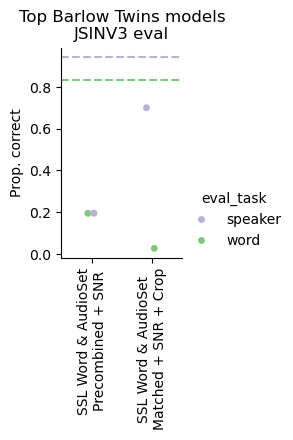

In [92]:
palette_set2 = sns.color_palette("Accent", 2)

palette={
    "word":palette_set2[0],
    "speaker":palette_set2[1]
}

best_speaker_from_paper = .94354
best_word_from_paper = .83459

# fig, axs = plt.subplots(figsize=(2,4))
g = sns.catplot(data=df, x='plot_name',
                # order=[ '[512, 512]', '[8192, 512]'],
                y='mean_acc', 
                hue='eval_task', hue_order=['speaker', 'word'],
                palette=palette,
                height=3, aspect=.74,  )#markers='.')

g.set_xticklabels( rotation=90)
g.axes[0][0].axhline(y=best_word_from_paper, color=palette['word'], ls='--', label='best supervised model')
g.axes[0][0].axhline(y=best_speaker_from_paper, color=palette['speaker'], ls='--', label='best supervised model')
# axs = g.axes[0][0]
# axs.set_yticks(np.linspace(0,.2, 5))
g.set(ylabel='Prop. correct', xlabel='', title="Top Barlow Twins models\nJSINV3 eval")
# g.set_titles("{col_name} task")

# plt.suptitle('JSINv3 eval of best Barlow-Twins models', y=1.1);
# plt.tight_layout()